1) **Basic Overview**
   - Shape (rows, columns
   - Data types (int, float, object, datetime
   - Preview (head, tail)

3) **Data Quality Checks**
   - Missing values (count + % per column)
   - Duplicates
   - Invalid values (e.g. negative ages, impossible dates)
   - Consistency (e.g. mixed formats in same column)
     
4) **Univariate Analysis (one variable at a time)**

   Numerical features:
   - Mean, median, std
   - Min / max
   - Distribution (histogram, KDE)
   - Outliers (boxplot)

   Categorical features:
   - Value counts
   - Frequency (%)
   - Rare categories
     
5) **Bivariate Analysis (relationships)**

   Numeric vs Numeric:
   - Scatter plots
   - Correlation (Pearson/Spearman)
     
   Categorical vs Numeric:
   - Grouped stats (mean target per category)
   - Boxplots
     
   Categorical vs Categorical:
   - Crosstab
   - Heatmaps
     

6) **Target Variable Analysis**

   Distribution of target
   - Imbalance (classification)
   - Outliers (regression)
   - Relationship with features

7) **Correlation & Multicollinearity**

   - Correlation matrix
   - Highly correlated features
   - Redundant variables
     
8) **Outliers Analysis**

   - Detect (IQR / Z-score / visual)
   - Understand: error or real signal?
   - Decide: keep / cap / remove

9) **Time-Based Analysis**

    - Trends over time
    - Aggregations (hours)
      
10) **Insights & desicions**



# Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns


# Imports

In [47]:
df = pd.read_csv(r'../data/interim_data/telaviv_buses_0704_1304_2024_cleaned_new_features.csv',encoding='utf-8-sig')

# 1. Basic Overview

In [48]:
### Df shape
df.shape

(92548, 37)

In [49]:
### Preview
df.head(5)

,date,day,hour_rounded,line_num,line_name,route_id,route_mkt,direction,alternative,agency_name,...,rainfall_mm,length_in_buffer_m,route_length,perc_within_pt_route,curvity,line_num_agency_alter_dir,urban,route_dir_alt_day_hr,Total_Passengers,Avg_Passengers_Per_Bus
0,2024-04-07,Sunday,0,826,ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->ד...,15123,10826,1,9,Egged,...,0.0,30946.992877,128214.134588,24.14,1.409145,Egged_826_1,False,10826_1_9_Sunday_0,1.0,1.0
1,2024-04-07,Sunday,0,61,מסוף עמידר-רמת גן<->מסוף כרמלית/הורדה-תל אביב ...,2512,16061,2,0,Dan,...,0.0,2595.473725,12742.652985,20.37,1.841781,Dan_61_2,False,16061_2_0_Sunday_0,13.0,6.5
2,2024-04-07,Sunday,0,63,הכובשים/דניאל-תל אביב יפו<->מסוף אלוף שדה-רמת ...,2517,17063,1,0,Dan,...,0.0,2833.152306,12232.226796,23.16,1.842028,Dan_63_1,False,17063_1_0_Sunday_0,9.0,9.0
3,2024-04-07,Sunday,0,70,ת.רכבת תל אביב - סבידור/רציפים C-תל אביב יפו<-...,2542,20070,1,0,Dan,...,0.0,4872.654308,10968.248411,44.43,1.791541,Dan_70_1,False,20070_1_0_Sunday_0,5.0,5.0
4,2024-04-07,Sunday,0,66,ת. מרכזית פ''ת/רציפים-פתח תקווה<->מסוף כרמלית/...,2532,15066,1,0,Dan,...,0.0,7989.261100,16464.450441,48.52,1.394338,Dan_66_1,False,15066_1_0_Sunday_0,12.0,12.0


In [50]:
### Data types
df.dtypes


date                          object
day                           object
hour_rounded                   int64
line_num                      object
line_name                     object
route_id                       int64
route_mkt                      int64
direction                      int64
alternative                   object
agency_name                   object
route_type                    object
origin_city                   object
origin_station                object
destination_city              object
destination_station           object
number_of_stops                int64
route_length_km              float64
departure_time_planned        object
arrival_time_planned          object
duration_min_planned         float64
duration_min_actual          float64
duration_difference_min      float64
speed_kmh_planned            float64
speed_kmh_actual             float64
gtfs_route_id                  int64
gtfs_ride_id                   int64
SIRI_id                        int64
r

In [54]:
df = df.drop(columns=['route_dir_alt_day_hr', 'line_num_agency_alter_dir', 'SIRI_id', 'gtfs_ride_id' ], errors='ignore')
df.dtypes


date                        object
day                         object
hour_rounded                 int64
line_num                    object
line_name                   object
route_id                     int64
route_mkt                    int64
direction                    int64
alternative                 object
agency_name                 object
route_type                  object
origin_city                 object
origin_station              object
destination_city            object
destination_station         object
number_of_stops              int64
route_length_km            float64
departure_time_planned      object
arrival_time_planned        object
duration_min_planned       float64
duration_min_actual        float64
duration_difference_min    float64
speed_kmh_planned          float64
speed_kmh_actual           float64
gtfs_route_id                int64
rainfall_mm                float64
length_in_buffer_m         float64
route_length               float64
perc_within_pt_route

In [53]:
df.head(5)

,date,day,hour_rounded,line_num,line_name,route_id,route_mkt,direction,alternative,agency_name,...,gtfs_ride_id,SIRI_id,rainfall_mm,length_in_buffer_m,route_length,perc_within_pt_route,curvity,urban,Total_Passengers,Avg_Passengers_Per_Bus
0,2024-04-07,Sunday,0,826,ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->ד...,15123,10826,1,9,Egged,...,72316307,67073403,0.0,30946.992877,128214.134588,24.14,1.409145,False,1.0,1.0
1,2024-04-07,Sunday,0,61,מסוף עמידר-רמת גן<->מסוף כרמלית/הורדה-תל אביב ...,2512,16061,2,0,Dan,...,72282601,67073416,0.0,2595.473725,12742.652985,20.37,1.841781,False,13.0,6.5
2,2024-04-07,Sunday,0,63,הכובשים/דניאל-תל אביב יפו<->מסוף אלוף שדה-רמת ...,2517,17063,1,0,Dan,...,72178343,67073417,0.0,2833.152306,12232.226796,23.16,1.842028,False,9.0,9.0
3,2024-04-07,Sunday,0,70,ת.רכבת תל אביב - סבידור/רציפים C-תל אביב יפו<-...,2542,20070,1,0,Dan,...,72179065,67073420,0.0,4872.654308,10968.248411,44.43,1.791541,False,5.0,5.0
4,2024-04-07,Sunday,0,66,ת. מרכזית פ''ת/רציפים-פתח תקווה<->מסוף כרמלית/...,2532,15066,1,0,Dan,...,72276232,67073424,0.0,7989.261100,16464.450441,48.52,1.394338,False,12.0,12.0


# 2. Data Quality Checks

## Missing values

In [52]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
duration_difference_min,19624,21.204132
duration_min_planned,19573,21.149025
speed_kmh_planned,19573,21.149025
Avg_Passengers_Per_Bus,2208,2.385789
Total_Passengers,2208,2.385789
curvity,1128,1.218827
perc_within_pt_route,1128,1.218827
route_length,1128,1.218827
length_in_buffer_m,1128,1.218827
agency_name,185,0.199896


In [56]:
selected_cols = [
    'departure_time_planned',
    'arrival_time_planned',
    'duration_min_planned',
    'duration_min_actual',
    'speed_kmh_planned',
    'speed_kmh_actual',
    'duration_difference_min'
]

(df[selected_cols].head())

,departure_time_planned,arrival_time_planned,duration_min_planned,duration_min_actual,speed_kmh_planned,speed_kmh_actual,duration_difference_min
0,00:00:00,02:20:48,NaN,143.0,NaN,49.2,NaN
1,00:00:00,00:39:59,NaN,57.0,NaN,11.9,NaN
2,00:00:00,00:41:59,42.0,44.0,15.1,14.4,2.0
3,00:00:00,00:20:59,21.0,28.0,27.9,20.9,7.0
4,00:00:00,00:49:06,NaN,50.0,NaN,18.6,NaN


### Fix the missing values

In [57]:
df['departure_time_planned'] = pd.to_datetime(df['departure_time_planned'], format='%H:%M:%S')
df['arrival_time_planned'] = pd.to_datetime(df['arrival_time_planned'], format='%H:%M:%S')

mask = df['duration_min_planned'].isna()
df.loc[mask, 'duration_min_planned'] = (
    (df.loc[mask, 'arrival_time_planned'] - df.loc[mask, 'departure_time_planned'])
    .dt.total_seconds() / 60
)

print(f"Missing values filled: {mask.sum()}")
(df[selected_cols].head())

Missing values filled: 19573


,departure_time_planned,arrival_time_planned,duration_min_planned,duration_min_actual,speed_kmh_planned,speed_kmh_actual,duration_difference_min
0,1900-01-01,1900-01-01 02:20:48,140.800000,143.0,NaN,49.2,NaN
1,1900-01-01,1900-01-01 00:39:59,39.983333,57.0,NaN,11.9,NaN
2,1900-01-01,1900-01-01 00:41:59,42.000000,44.0,15.1,14.4,2.0
3,1900-01-01,1900-01-01 00:20:59,21.000000,28.0,27.9,20.9,7.0
4,1900-01-01,1900-01-01 00:49:06,49.100000,50.0,NaN,18.6,NaN


In [58]:
mask2 = df['duration_difference_min'].isna()
df.loc[mask2, 'duration_difference_min'] = (
    df.loc[mask2, 'duration_min_actual'] - df.loc[mask2, 'duration_min_planned']
)

print(f"Missing values filled: {mask2.sum()}")
(df[selected_cols].head())

Missing values filled: 19624


,departure_time_planned,arrival_time_planned,duration_min_planned,duration_min_actual,speed_kmh_planned,speed_kmh_actual,duration_difference_min
0,1900-01-01,1900-01-01 02:20:48,140.800000,143.0,NaN,49.2,2.200000
1,1900-01-01,1900-01-01 00:39:59,39.983333,57.0,NaN,11.9,17.016667
2,1900-01-01,1900-01-01 00:41:59,42.000000,44.0,15.1,14.4,2.000000
3,1900-01-01,1900-01-01 00:20:59,21.000000,28.0,27.9,20.9,7.000000
4,1900-01-01,1900-01-01 00:49:06,49.100000,50.0,NaN,18.6,0.900000


In [79]:
mask3 = df['speed_kmh_planned'].isna()
df.loc[mask3, 'speed_kmh_planned'] = (
    (df.loc[mask3, 'route_length'] / 1000) / (df.loc[mask3, 'duration_min_planned'] / 60)
)

print(f"Missing values filled: {mask3.sum()}")
print(df[selected_cols].head())

Missing values filled: 236
  departure_time_planned arrival_time_planned  duration_min_planned  \
0             1900-01-01  1900-01-01 02:20:48            140.800000   
1             1900-01-01  1900-01-01 00:39:59             39.983333   
2             1900-01-01  1900-01-01 00:41:59             42.000000   
3             1900-01-01  1900-01-01 00:20:59             21.000000   
4             1900-01-01  1900-01-01 00:49:06             49.100000   

   duration_min_actual  speed_kmh_planned  speed_kmh_actual  \
0                143.0       54636.705080              49.2   
1                 57.0       19121.946955              11.9   
2                 44.0          15.100000              14.4   
3                 28.0          27.900000              20.9   
4                 50.0       20119.491374              18.6   

   duration_difference_min  
0                 2.200000  
1                17.016667  
2                 2.000000  
3                 7.000000  
4                 0.90

In [80]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
Avg_Passengers_Per_Bus,2208,2.385789
Total_Passengers,2208,2.385789
curvity,1128,1.218827
perc_within_pt_route,1128,1.218827
route_length,1128,1.218827
length_in_buffer_m,1128,1.218827
speed_kmh_planned,236,0.255003
agency_name,185,0.199896
duration_min_actual,128,0.138307
duration_difference_min,128,0.138307


## Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

## Invalid values

The following validation checks were applied to assess data quality:

- `date` — invalid date values after converting from string to datetime
- `hour` — values smaller than 0 or larger than 23
- `number_of_stops` — values smaller than or equal to 0
- `route_length_km` — values smaller than or equal to 0
- `rainfall_mm` — negative values
- `length_in_buffer_m` — negative values
- `duration_min_planned` — values smaller than or equal to 0
- `duration_min_actual` — values smaller than or equal to 0
- `route_length` — values smaller than or equal to 0
- `perc_within_pt_route` — negative values
- `curvity` — values smaller than 1
- `Total_Passengers` — negative values
- `Avg_Passengers_Per_Bus` — negative values

In [9]:
# Copy dataframe if you want to avoid changing the original
df_checked = df.copy()

# Convert date column from string to datetime
# Invalid parsing will become NaT
df_checked['date_converted'] = pd.to_datetime(df_checked['date'], errors='coerce')

# Define invalid value checks
checks = {
    'date_invalid': df_checked['date_converted'].isna(),
    'hour_invalid': (df_checked['hour_rounded'] < 0) | (df_checked['hour_rounded'] > 23),
    'number_of_stops_invalid': df_checked['number_of_stops'] <= 0,
    'route_length_km_invalid': df_checked['route_length_km'] <= 0,
    'rainfall_mm_invalid': df_checked['rainfall_mm'] < 0,
    'length_in_buffer_m_invalid': df_checked['length_in_buffer_m'] < 0,
    'duration_min_planned_invalid': df_checked['duration_min_planned'] <= 0,
    'duration_min_actual_invalid': df_checked['duration_min_actual'] <= 0,
    'route_length_invalid': df_checked['route_length'] <= 0,
    'perc_within_pt_route_invalid': df_checked['perc_within_pt_route'] < 0,
    'curvity_invalid': df_checked['curvity'] < 1,
    'Total_Passengers_invalid': df_checked['Total_Passengers'] < 0,
    'Avg_Passengers_Per_Bus_invalid': df_checked['Avg_Passengers_Per_Bus'] < 0
}

# Build summary table
invalid_summary = pd.DataFrame({
    'Check': list(checks.keys()),
    'Invalid Count': [condition.sum() for condition in checks.values()],
    'Invalid %': [condition.mean() * 100 for condition in checks.values()]
})

invalid_summary['Invalid %'] = invalid_summary['Invalid %'].round(2)

invalid_summary = invalid_summary.sort_values('Invalid %', ascending=False).reset_index(drop=True)

invalid_summary

,Check,Invalid Count,Invalid %
0,date_invalid,0,0.0
1,hour_invalid,0,0.0
2,number_of_stops_invalid,0,0.0
3,route_length_km_invalid,0,0.0
4,rainfall_mm_invalid,0,0.0
5,length_in_buffer_m_invalid,0,0.0
6,duration_min_planned_invalid,0,0.0
7,duration_min_actual_invalid,0,0.0
8,route_length_invalid,0,0.0
9,perc_within_pt_route_invalid,0,0.0


## Consistency

In [10]:
consistency_overview = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique(),
    'sample_values': df.apply(lambda x: x.dropna().astype(str).unique()[:3])
})

consistency_overview

,dtype,unique_values,sample_values
date,object,7,"[2024-04-07, 2024-04-08, 2024-04-09]"
day,object,7,"[Sunday, Monday, Tuesday]"
hour_rounded,int64,24,"[0, 1, 2]"
line_num,object,298,"[826, 61, 63]"
line_name,object,631,[ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->...
route_id,int64,715,"[15123, 2512, 2517]"
route_mkt,int64,305,"[10826, 16061, 17063]"
direction,int64,3,"[1, 2, 3]"
alternative,object,30,"[9, 0, #]"
agency_name,object,10,"[Egged, Dan, Metropolin]"


# 3. Univariate Analysis

In [62]:
### splitting to numeric and categorial columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

## Numeric columns

In [63]:
### Summary statistics

num_summary = df[numeric_cols].describe().T

num_summary = num_summary[['mean', '50%', 'std', 'min', 'max']]
num_summary = num_summary.rename(columns={'50%': 'median'})

num_summary

,mean,median,std,min,max
hour_rounded,1.282100e+01,1.300000e+01,5.229215,0.000000e+00,2.300000e+01
route_id,1.149116e+04,9.780000e+03,10325.973620,3.900000e+01,3.834300e+04
route_mkt,1.999235e+04,1.504200e+04,15189.293952,1.011200e+04,9.900200e+04
direction,1.496078e+00,1.000000e+00,0.512832,1.000000e+00,3.000000e+00
number_of_stops,3.931763e+01,4.000000e+01,13.075301,2.000000e+00,1.070000e+02
route_length_km,2.429382e+01,1.787900e+01,24.520324,3.190000e+00,3.213640e+02
duration_min_planned,4.909459e+01,5.100000e+01,91.793236,-1.419017e+03,3.320000e+02
duration_min_actual,7.148461e+01,6.900000e+01,36.331133,1.000000e+00,1.105000e+03
duration_difference_min,2.240292e+01,1.700000e+01,93.976666,-2.530000e+02,1.716017e+03
speed_kmh_planned,5.563382e+03,2.260000e+01,12216.495055,-1.915178e+04,8.509144e+04


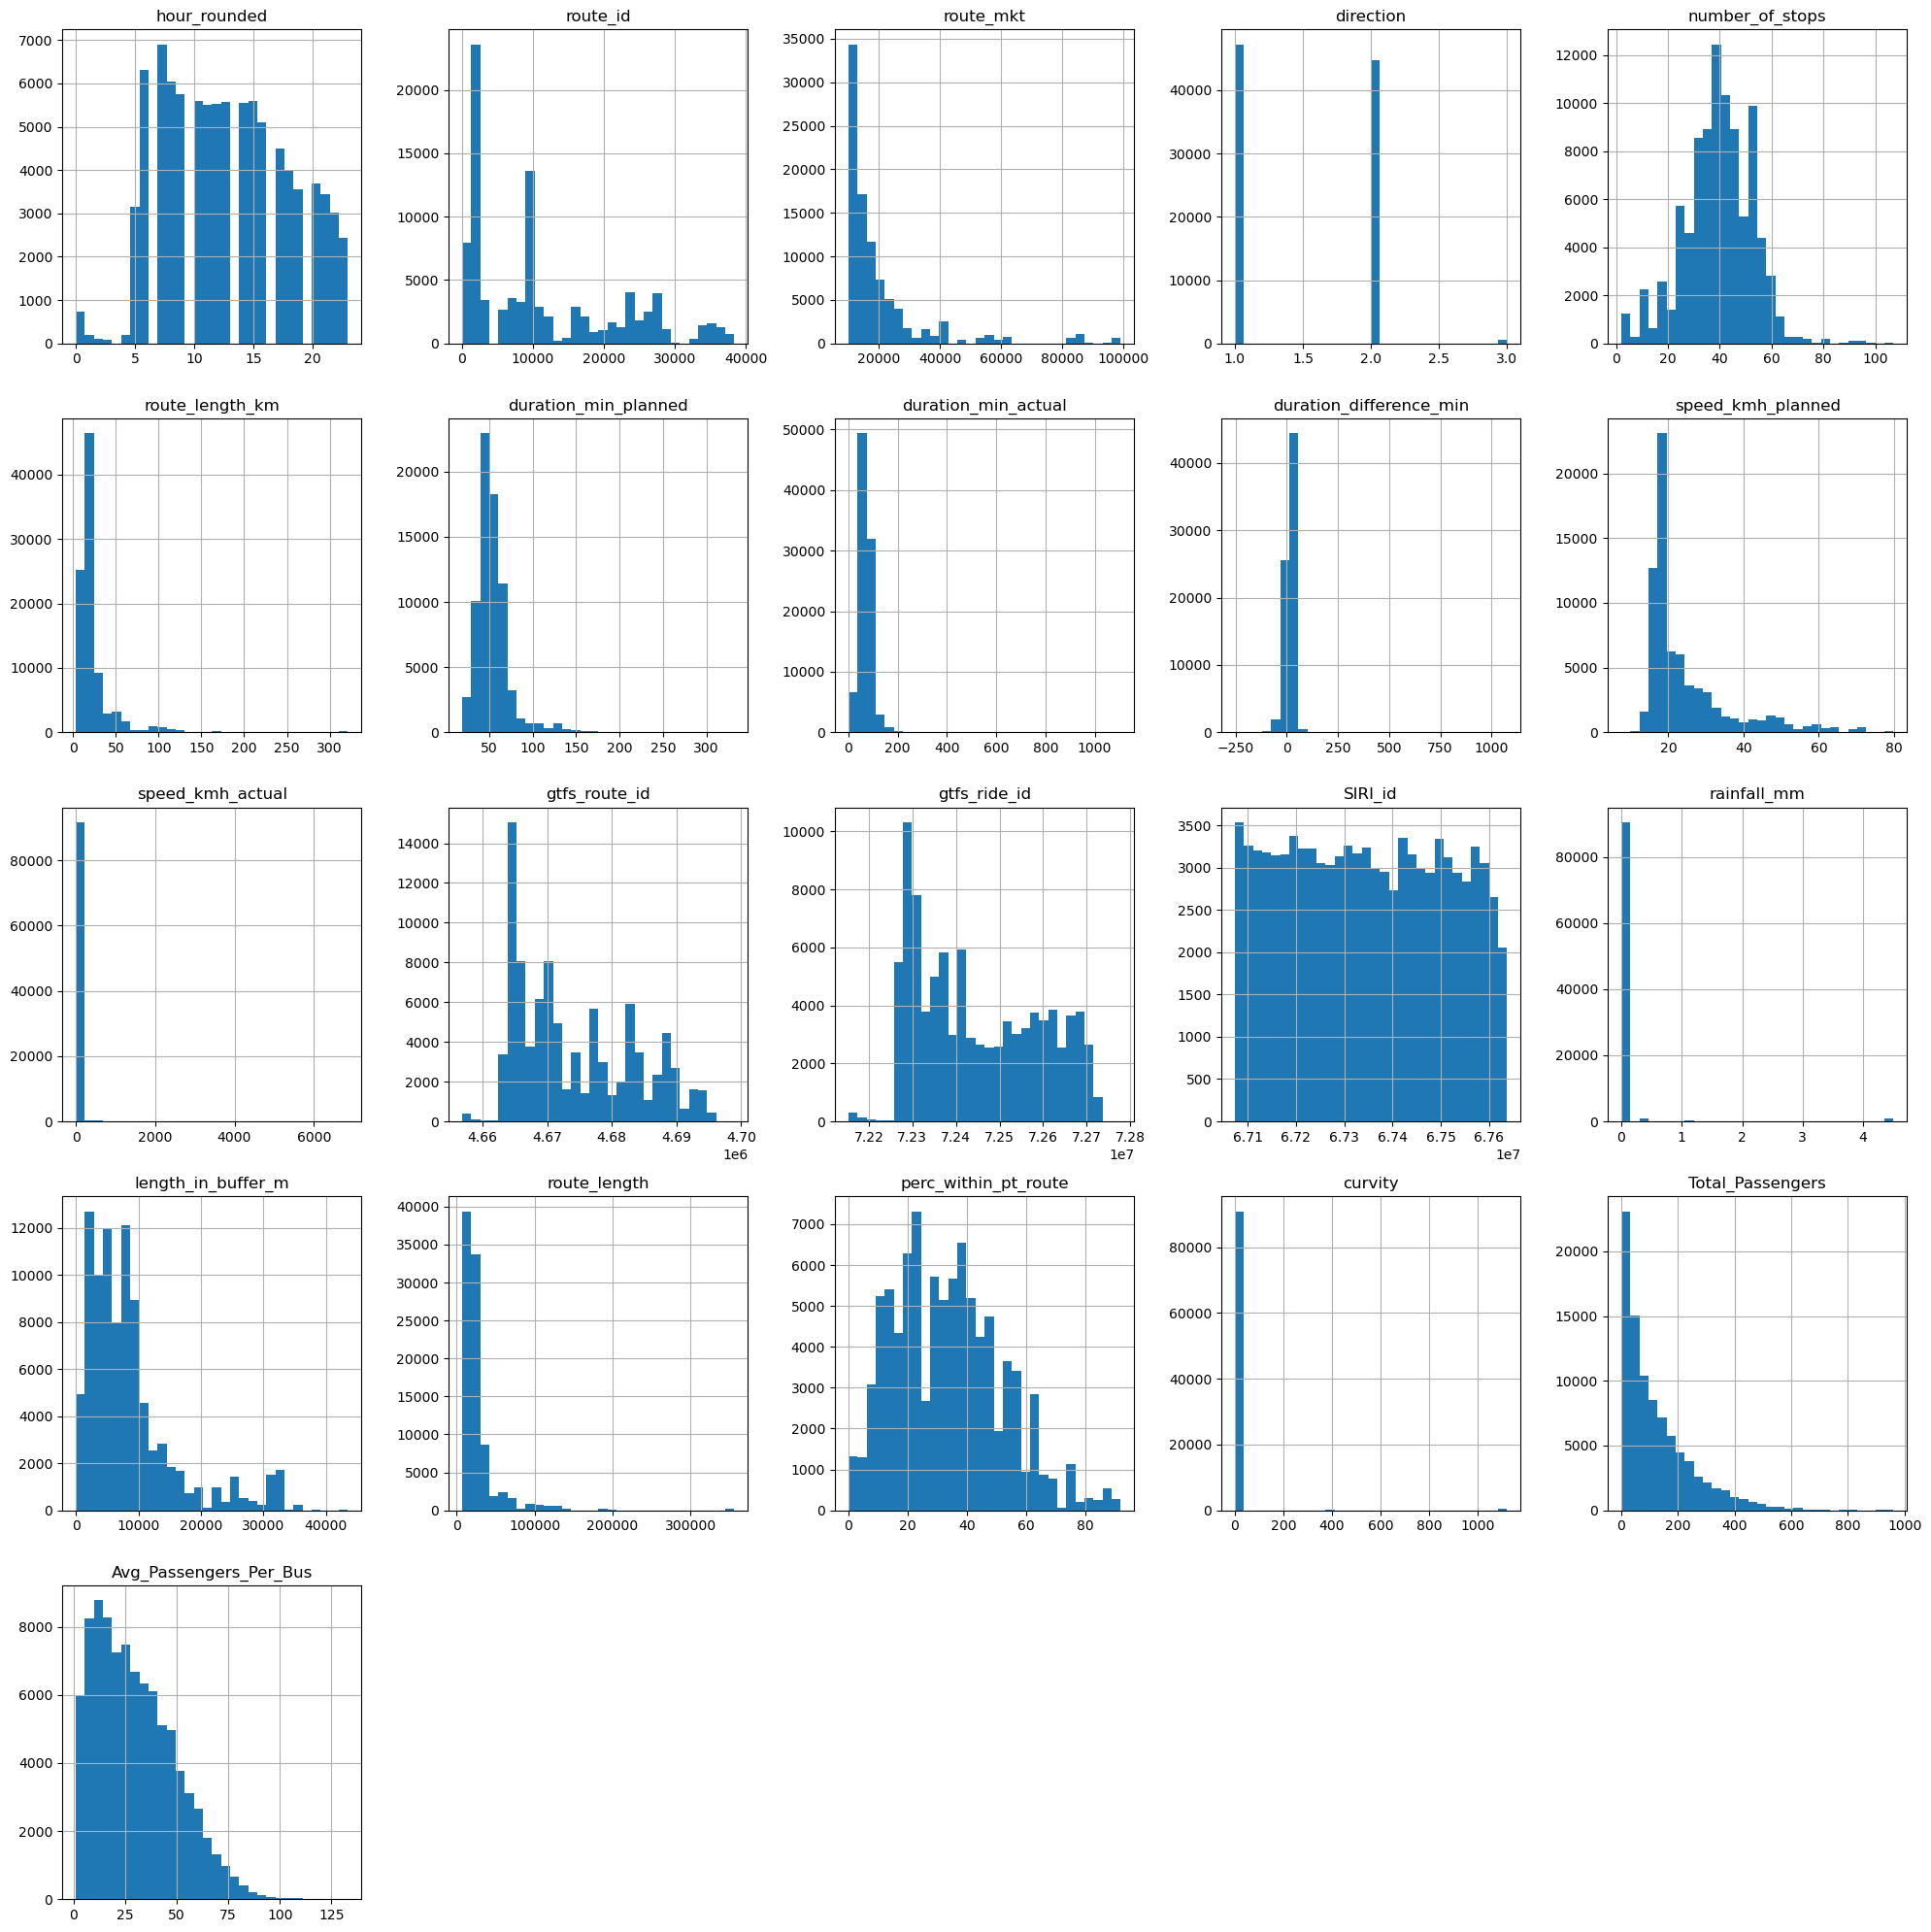

In [13]:
import matplotlib.pyplot as plt
import math

cols = numeric_cols
n_cols = 5
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].dropna().hist(ax=axes[i], bins=30)
    axes[i].set_title(col)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

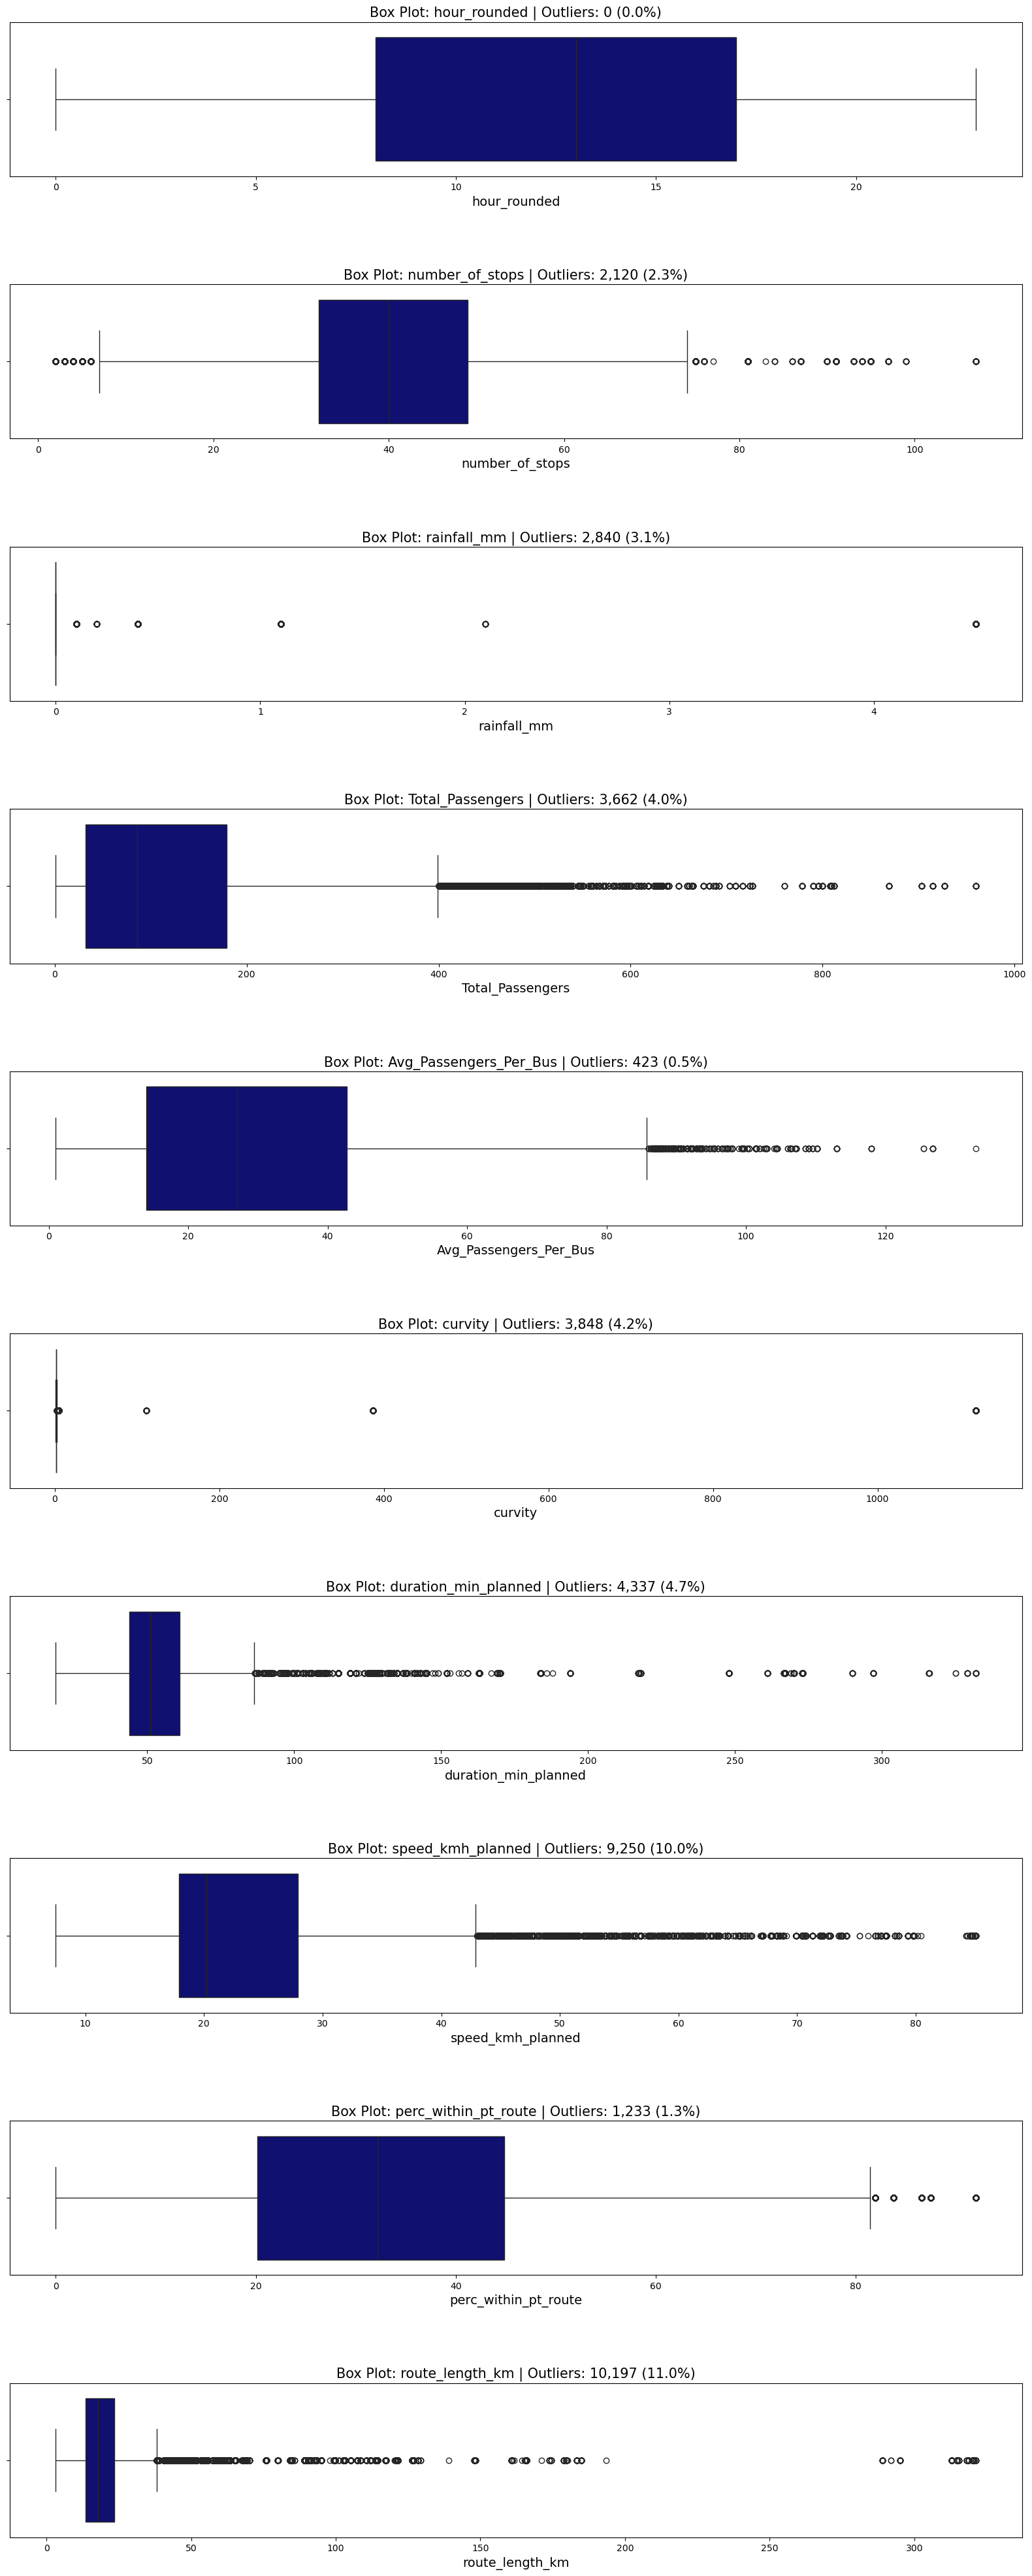

In [92]:
plt.figure(figsize=(20, 50))
cols = ['hour_rounded', 'number_of_stops', 'rainfall_mm', 'Total_Passengers', 'Avg_Passengers_Per_Bus', 
        'curvity', 'duration_min_planned', 'speed_kmh_planned', 'perc_within_pt_route', 'route_length_km']

for i, col in enumerate(cols):
    ax = plt.subplot(len(cols), 1, i + 1)
    sns.boxplot(data=df, x=col, ax=ax, color='navy')
    plt.subplots_adjust(hspace=0.7)
    
    # חישוב outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = len(df[(df[col] < lower) | (df[col] > upper)])
    pct_outliers = n_outliers / len(df) * 100
    
    plt.title(f'Box Plot: {col} | Outliers: {n_outliers:,} ({pct_outliers:.1f}%)', fontsize=15)
    plt.xlabel(col, fontsize=14)

plt.show()

### check the outliers

#### long routes

In [75]:
df[df['route_length_km'] > 150].head(2)

#### those are Eilat routes - its OK

,date,day,hour_rounded,line_num,line_name,route_id,route_mkt,direction,alternative,agency_name,...,speed_kmh_actual,gtfs_route_id,rainfall_mm,length_in_buffer_m,route_length,perc_within_pt_route,curvity,urban,Total_Passengers,Avg_Passengers_Per_Bus
44,2024-04-07,Sunday,0,840,ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->ת...,19732,10840,1,#,Egged,...,52.1,4660979,0.0,30947.379382,197027.483135,15.71,1.331509,False,3.0,3.0
242,2024-04-07,Sunday,4,390,ת. מרכזית אילת/רציפים-אילת<->ת.מרכזית תל אביב ...,5170,10390,2,#,Egged,...,61.3,4657727,0.0,12694.581432,348977.173773,3.64,1.257403,False,NaN,NaN


#### VERY High and low Speed Plan

In [83]:
df[df['speed_kmh_planned'] > 1000][['route_length', 'duration_min_planned', 'departure_time_planned', 'arrival_time_planned', 'speed_kmh_planned']].head(2)

,route_length,duration_min_planned,departure_time_planned,arrival_time_planned,speed_kmh_planned
0,128214.134588,140.800000,1900-01-01,1900-01-01 02:20:48,54636.705080
1,12742.652985,39.983333,1900-01-01,1900-01-01 00:39:59,19121.946955


In [86]:
mask_high = df['speed_kmh_planned'] > 100
print(f"Rows with speed > 100: {mask_high.sum()}")

df.loc[mask_high, 'speed_kmh_planned'] = df.loc[mask_high, 'speed_kmh_planned'] / 1000

print(df['speed_kmh_planned'].describe())

Rows with speed > 100: 0
count    92312.000000
mean        19.154578
std        176.960798
min     -19151.780351
25%         17.900000
50%         20.119491
75%         27.800000
max         85.091445
Name: speed_kmh_planned, dtype: float64


In [89]:
df[df['speed_kmh_planned'] < 0][['date', 'route_length', 'duration_min_planned', 'departure_time_planned', 'arrival_time_planned', 'speed_kmh_planned']].head(10)

## It looks like it happend because the ries ends in the next day

,date,route_length,duration_min_planned,departure_time_planned,arrival_time_planned,speed_kmh_planned
16507,2024-04-07,353701.463448,-1108.100000,1900-01-01 19:00:00,1900-01-01 00:31:54,-19151.780351
16508,2024-04-07,353701.463448,-1108.100000,1900-01-01 19:00:00,1900-01-01 00:31:54,-19151.780351
17818,2024-04-07,198288.157852,-1222.783333,1900-01-01 20:30:00,1900-01-01 00:07:13,-9729.679124
18137,2024-04-07,197027.483135,-1222.016667,1900-01-01 21:00:00,1900-01-01 00:37:59,-9673.885235
18536,2024-04-07,198288.157852,-1222.783333,1900-01-01 21:30:00,1900-01-01 01:07:13,-9729.679124
18705,2024-04-07,129365.087959,-1301.733333,1900-01-01 21:45:00,1900-01-01 00:03:16,-5962.746039
18760,2024-04-07,116616.363216,-1308.316667,1900-01-01 21:50:00,1900-01-01 00:01:41,-5348.079690
18875,2024-04-07,197027.483135,-1222.016667,1900-01-01 22:00:00,1900-01-01 01:37:59,-9673.885235
18915,2024-04-07,128214.134588,-1299.200000,1900-01-01 22:00:00,1900-01-01 00:20:48,-5921.219270
19065,2024-04-07,74279.287698,-1312.166667,1900-01-01 22:20:00,1900-01-01 00:27:50,-3396.487180


In [91]:
# זהה נסיעות שמסתיימות אחרי חצות
mask_midnight = df['arrival_time_planned'] < df['departure_time_planned']
print(f"Trips ending after midnight: {mask_midnight.sum()}")

# תקן את duration_min_planned
df.loc[mask_midnight, 'duration_min_planned'] = (
    (df.loc[mask_midnight, 'arrival_time_planned'] + pd.Timedelta(days=1)) - 
    df.loc[mask_midnight, 'departure_time_planned']
).dt.total_seconds() / 60

# תקן את speed_kmh_planned
df.loc[mask_midnight, 'speed_kmh_planned'] = (
    (df.loc[mask_midnight, 'route_length'] / 1000) / 
    (df.loc[mask_midnight, 'duration_min_planned'] / 60)
)

(df[mask_midnight][['departure_time_planned', 'arrival_time_planned', 
                          'duration_min_planned', 'speed_kmh_planned']].head())

Trips ending after midnight: 1910


,departure_time_planned,arrival_time_planned,duration_min_planned,speed_kmh_planned
16507,1900-01-01 19:00:00,1900-01-01 00:31:54,331.900000,63.941211
16508,1900-01-01 19:00:00,1900-01-01 00:31:54,331.900000,63.941211
17818,1900-01-01 20:30:00,1900-01-01 00:07:13,217.216667,54.771531
18137,1900-01-01 21:00:00,1900-01-01 00:37:59,217.983333,54.231894
18536,1900-01-01 21:30:00,1900-01-01 01:07:13,217.216667,54.771531


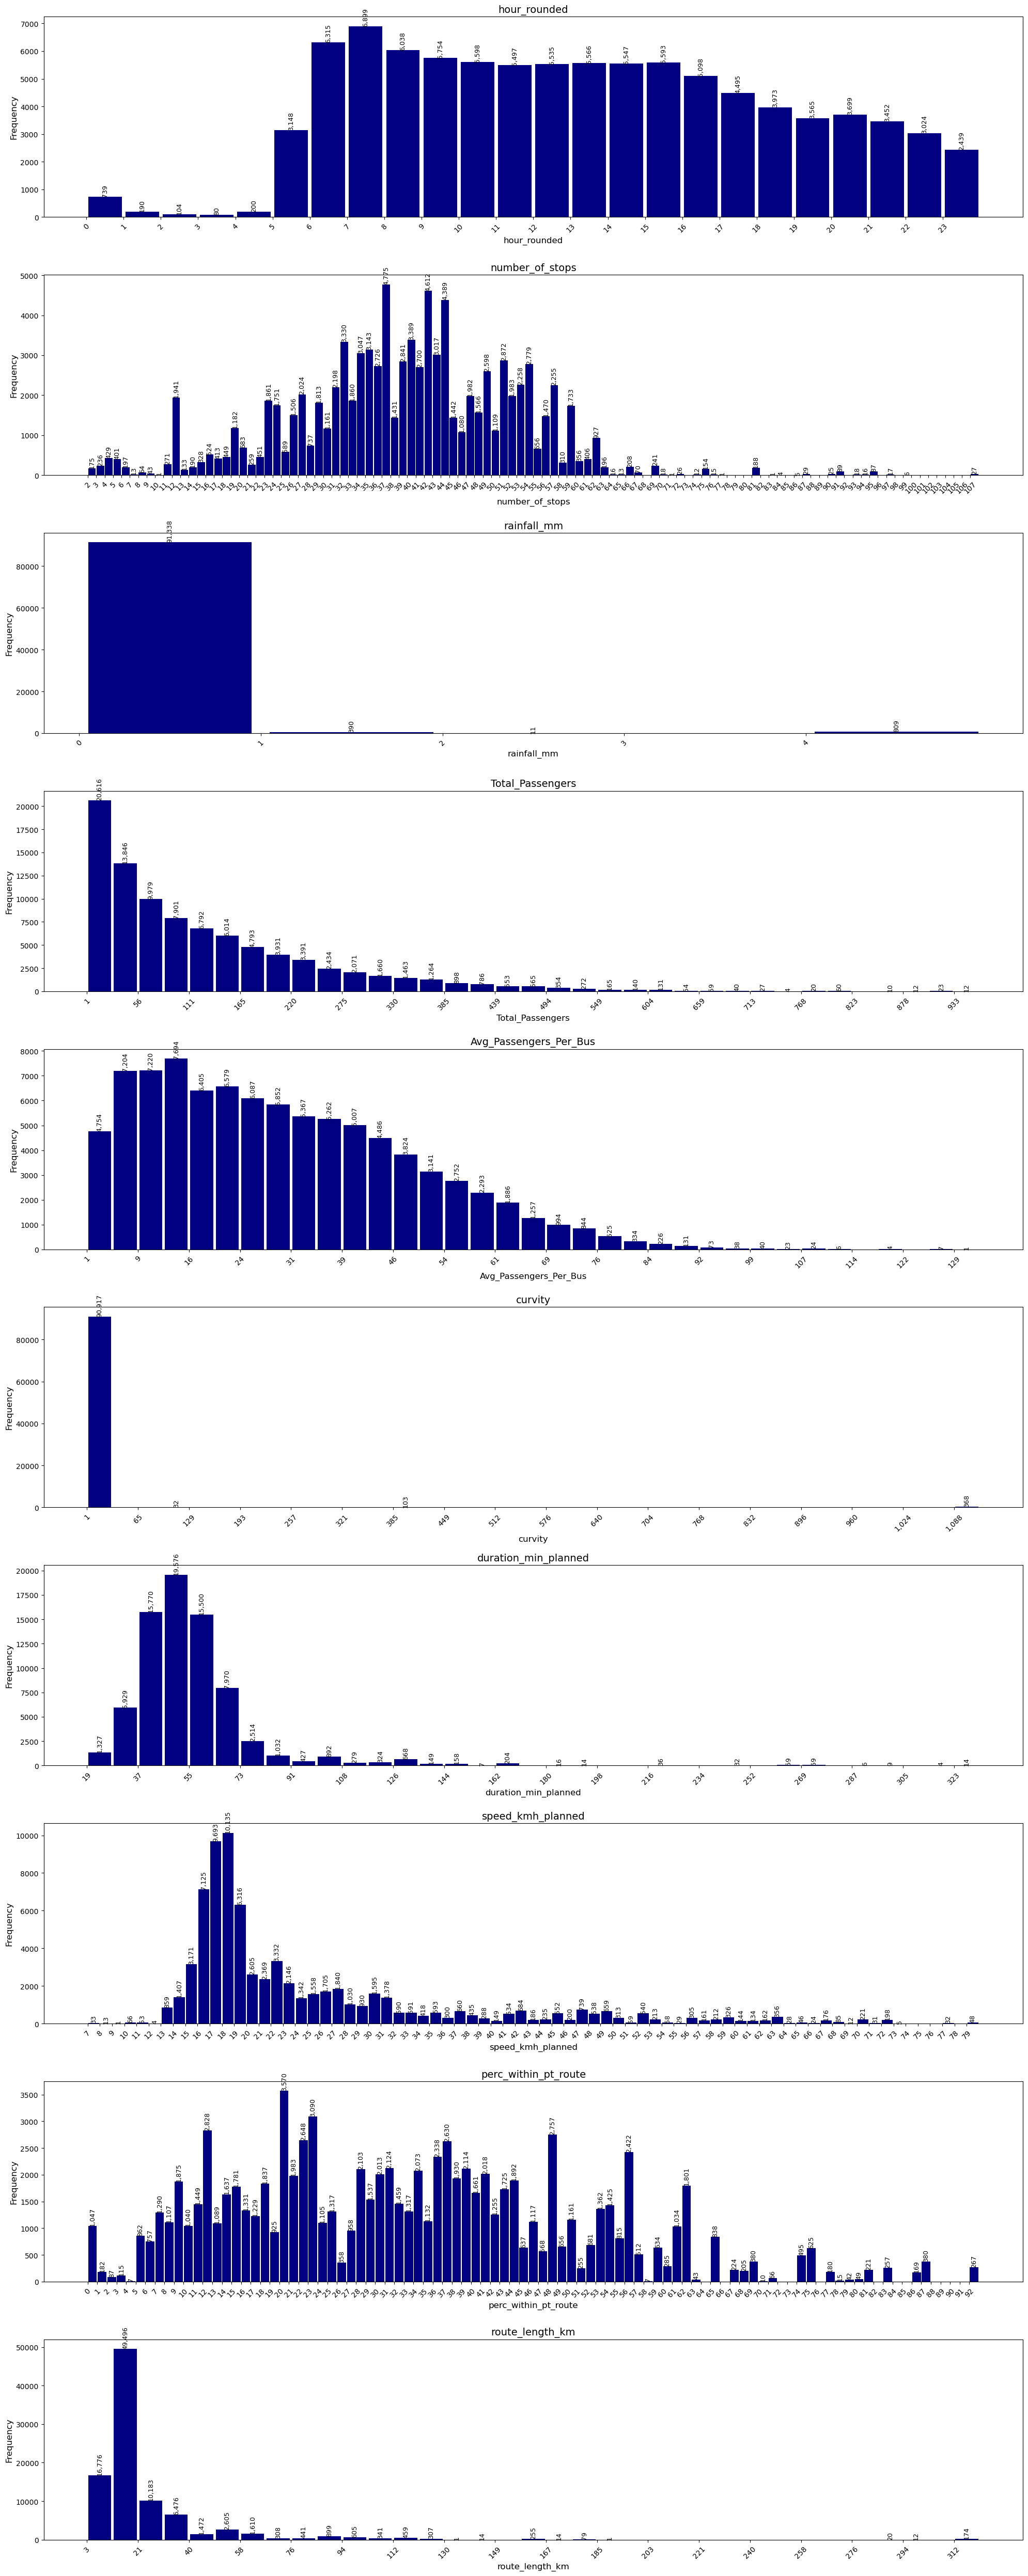

In [30]:
cols = ['hour_rounded', 'number_of_stops', 'rainfall_mm', 'Total_Passengers', 'Avg_Passengers_Per_Bus', 'curvity', 'duration_min_planned', 'speed_kmh_planned' ,'perc_within_pt_route', 'route_length_km' ]
continuous_cols = ['Total_Passengers', 'Avg_Passengers_Per_Bus', 'curvity', 'duration_min_planned','route_length_km']
con_df = df[cols]

fig, axes = plt.subplots(len(cols), 1, figsize=(20, 50))

for i, col in enumerate(cols):
    if col in continuous_cols:
        counts, bins_out, patches = axes[i].hist(con_df[col].dropna(), bins=35, color='navy', rwidth=0.9)
        axes[i].set_xticks(bins_out[::2])
        axes[i].set_xticklabels([f'{int(round(b)):,}' for b in bins_out[::2]], rotation=45, fontsize=10)
    else:
        min_val = int(con_df[col].dropna().min())
        max_val = int(con_df[col].dropna().max())
        bins = range(min_val, max_val + 2)
        counts, bins_out, patches = axes[i].hist(con_df[col].dropna(), bins=bins, color='navy', rwidth=0.9)
        axes[i].set_xticks(range(min_val, max_val + 1))
        axes[i].set_xticklabels(range(min_val, max_val + 1), rotation=45, fontsize=10)

    axes[i].set_title(col, fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)

    for patch, count in zip(patches, counts):
        if count > 0:
            axes[i].text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_height() + 0.5,
                f'{int(count):,}',
                ha='center', va='bottom', fontsize=9, rotation=90
            )

plt.tight_layout()
plt.show()

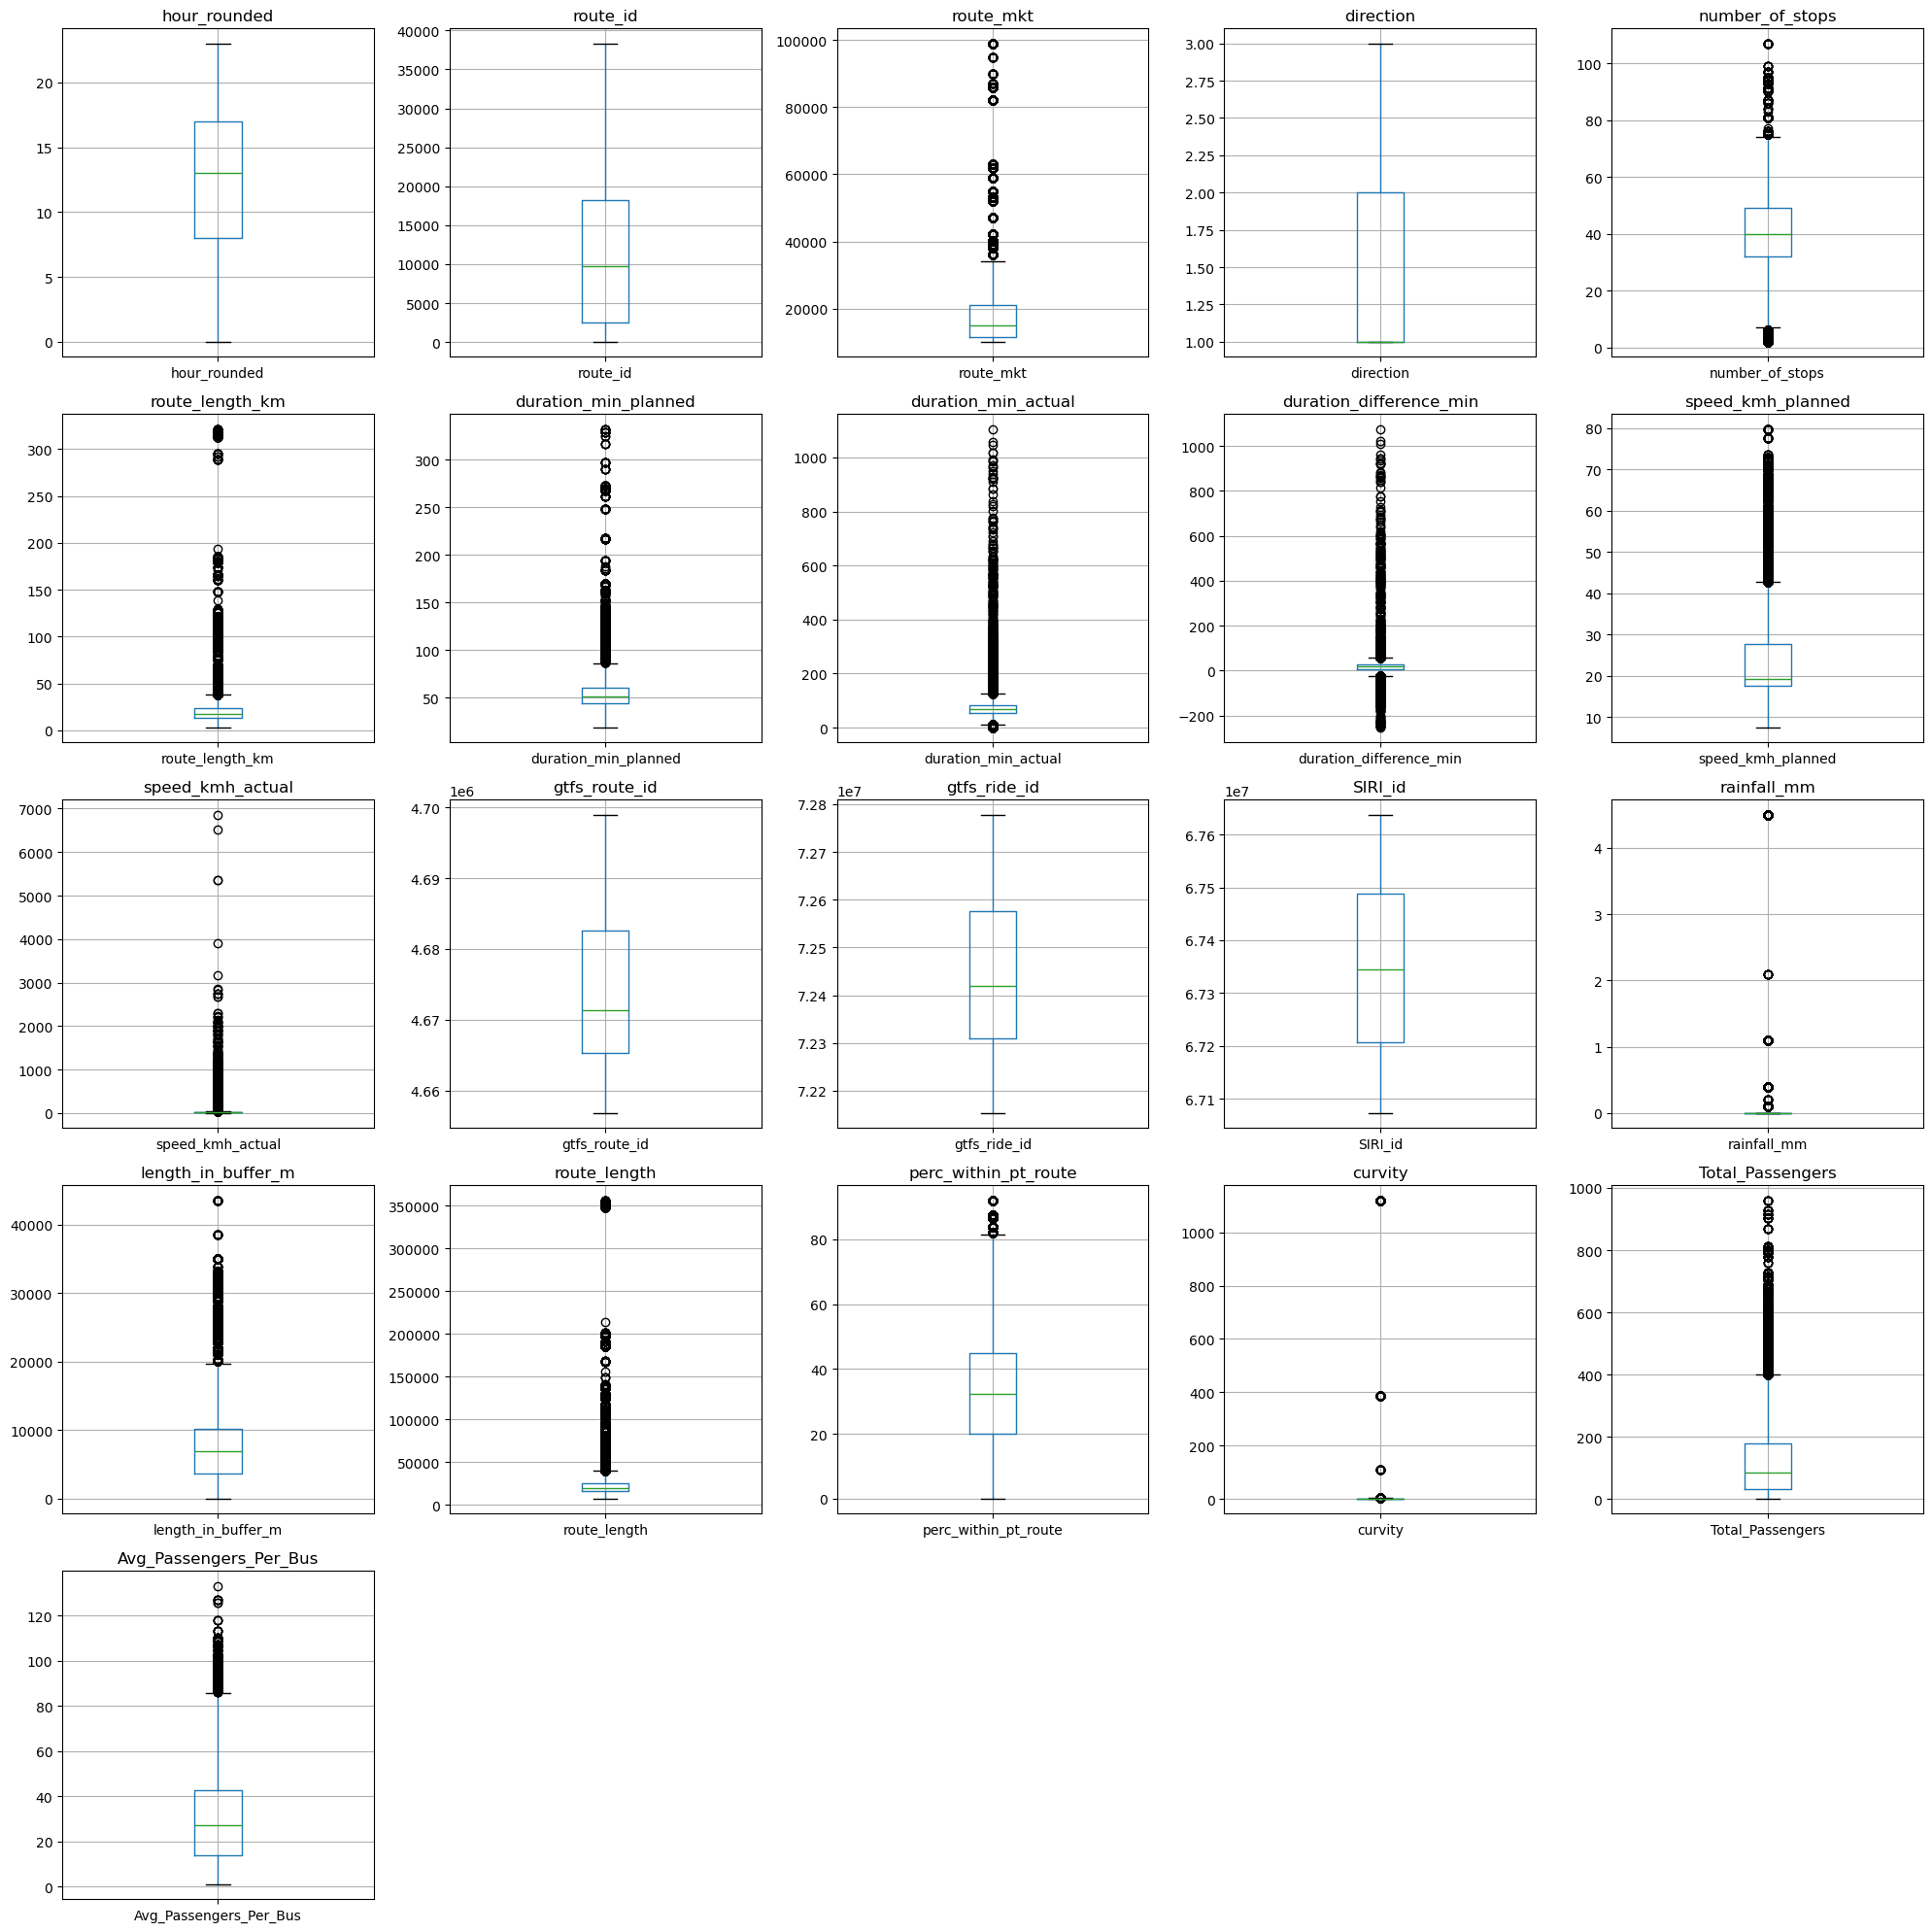

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Categorial

C:\Users\shaha\AppData\Local\Temp\ipykernel_9324\871371952.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


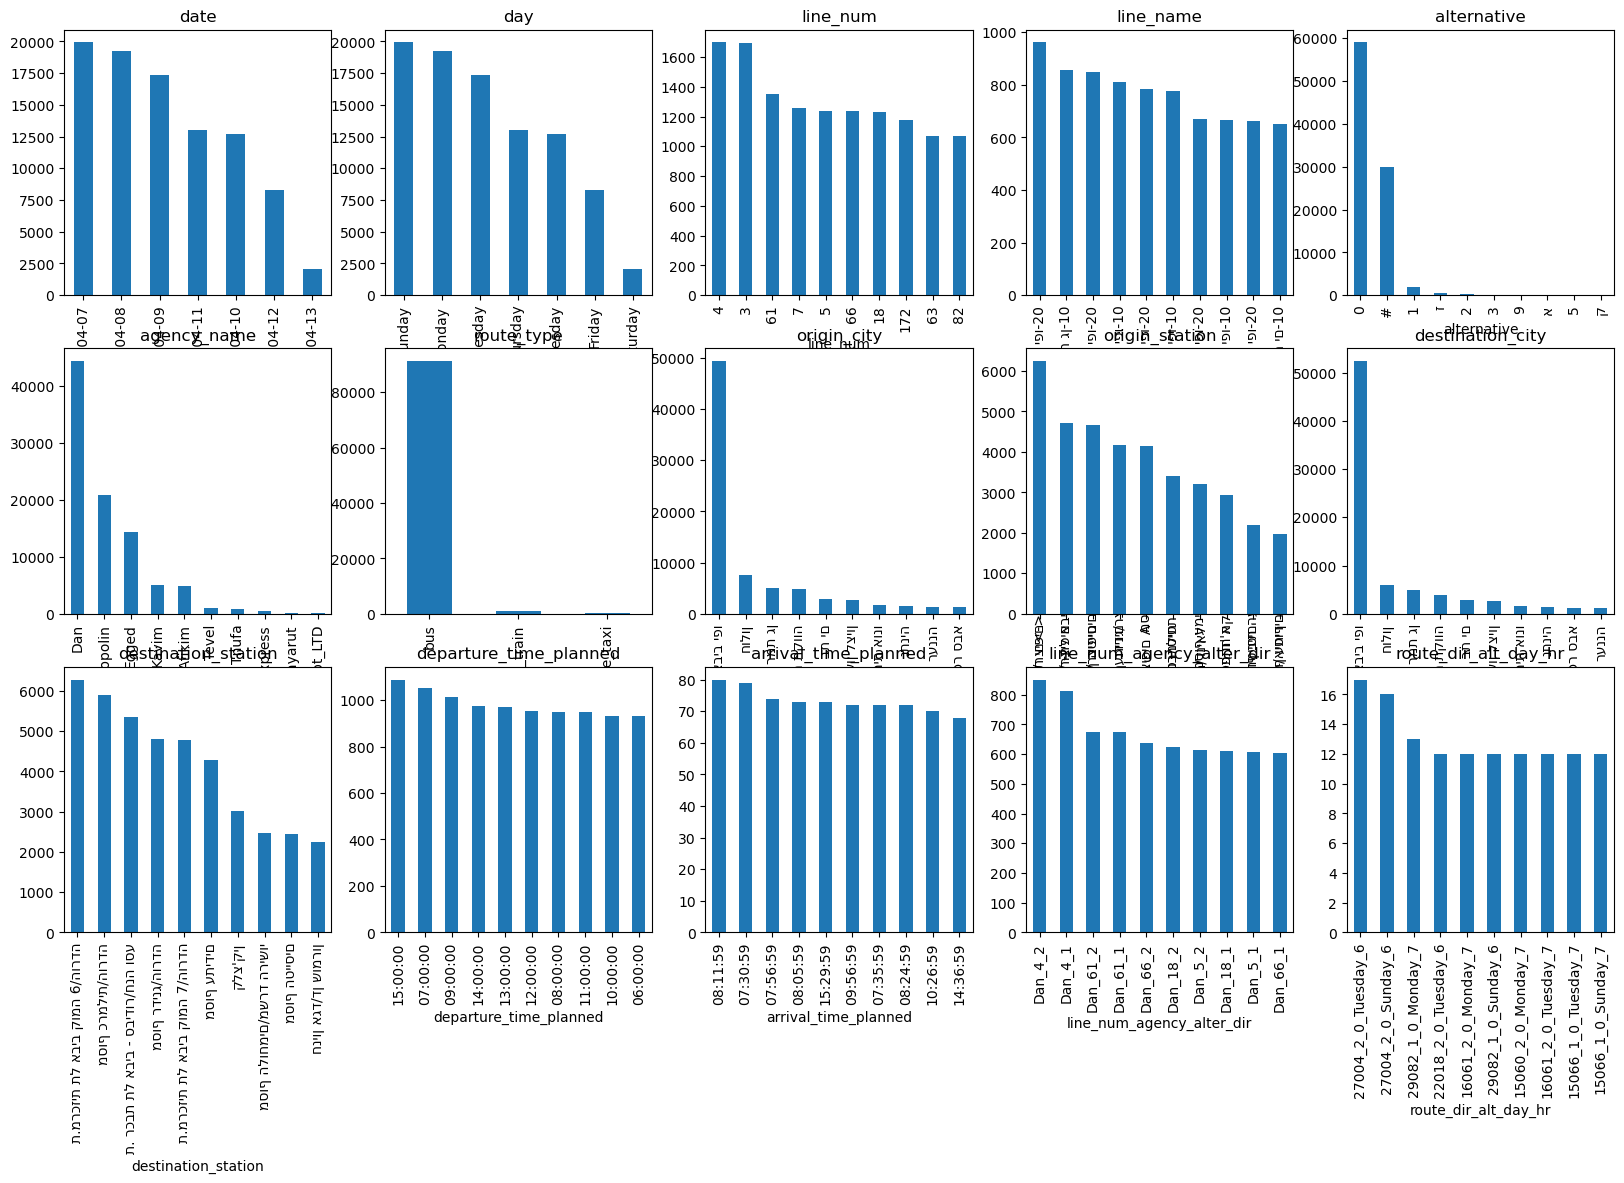

In [51]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [33]:
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)

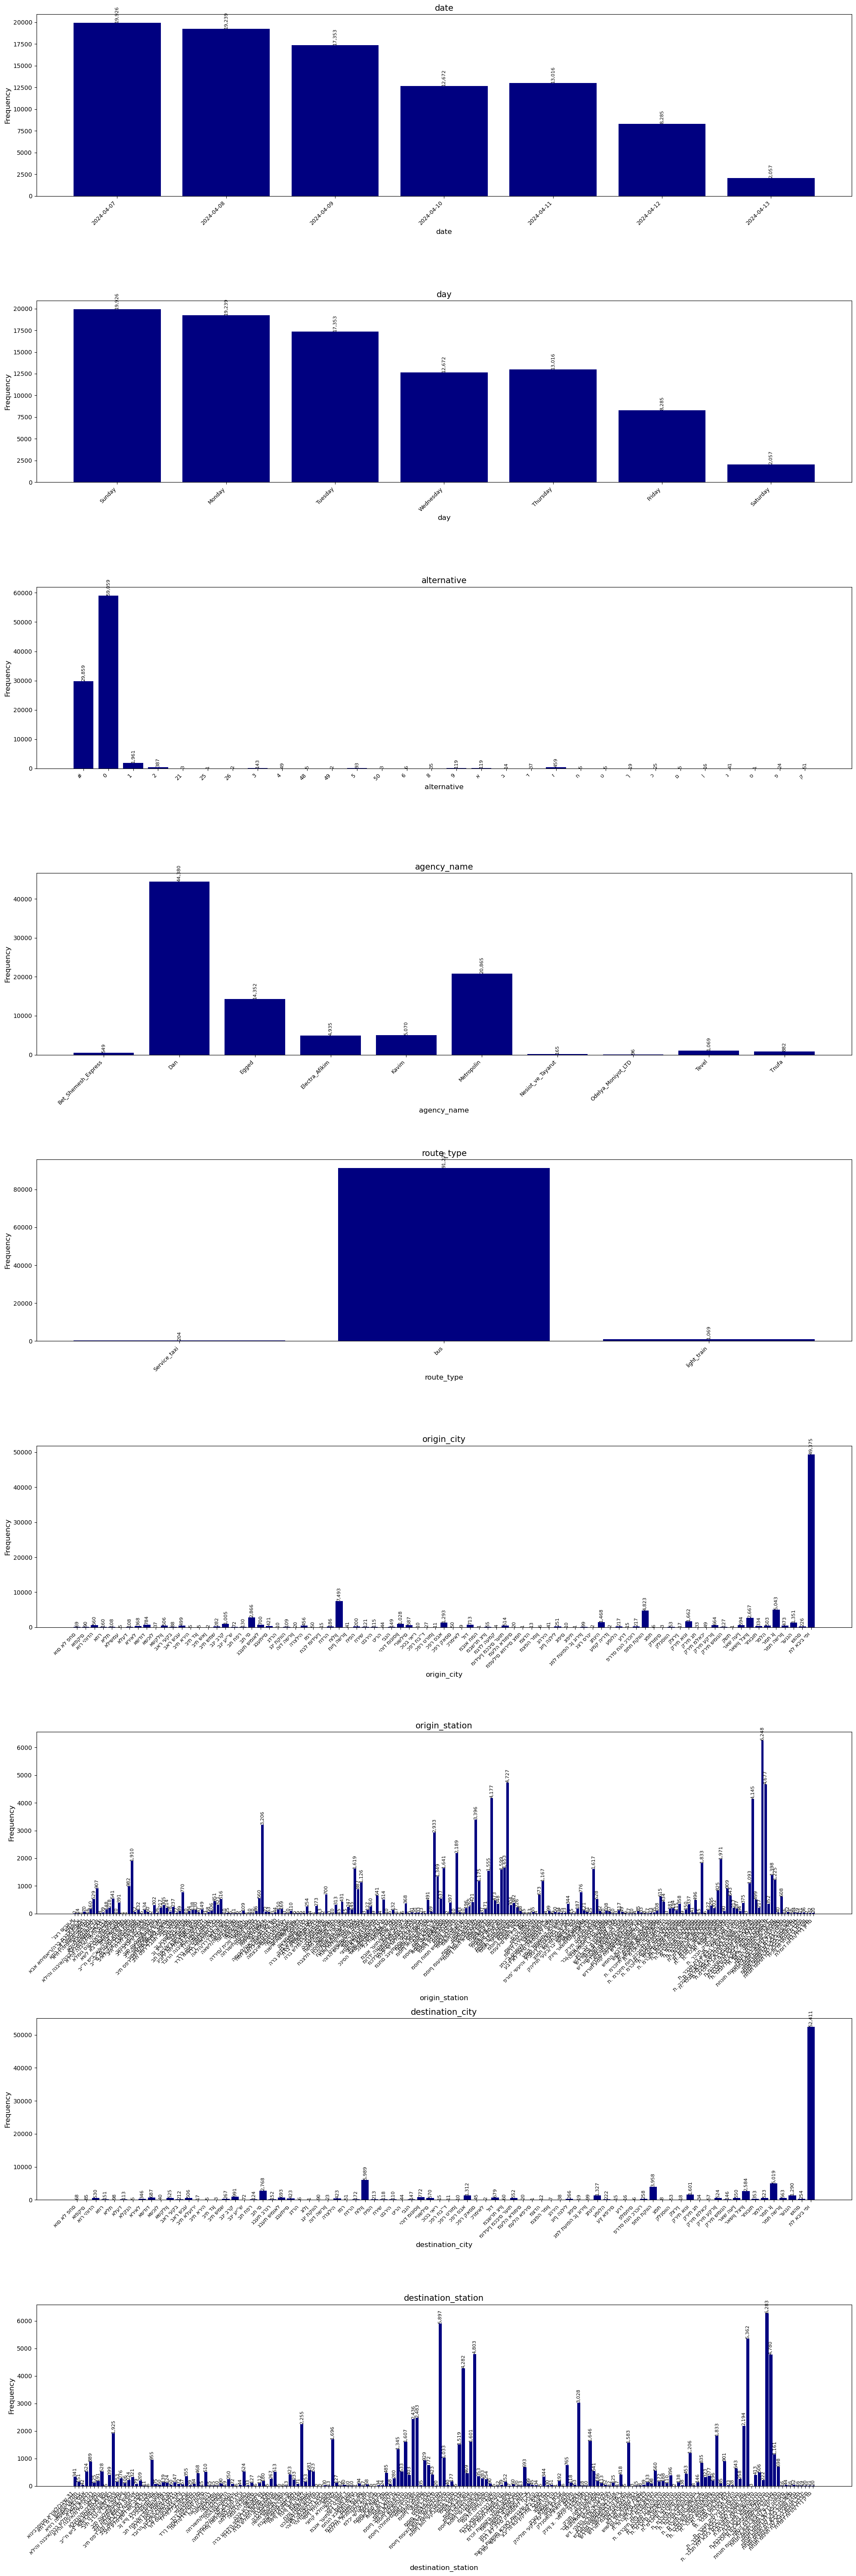

In [34]:
cat_cols = ['date', 'day', 'alternative', 'agency_name', 'route_type', 'origin_city', 'origin_station', 'destination_city', 'destination_station']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(20, 60))

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts().sort_index()
    bars = axes[i].bar(range(len(value_counts)), value_counts.values, color='navy')
    axes[i].set_title(col, fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)

    for bar, count in zip(bars, value_counts.values):
        if count > 0:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{int(count):,}',
                ha='center', va='bottom', fontsize=8, rotation=90
            )

plt.tight_layout()
plt.show()

# 5. Target Analysis

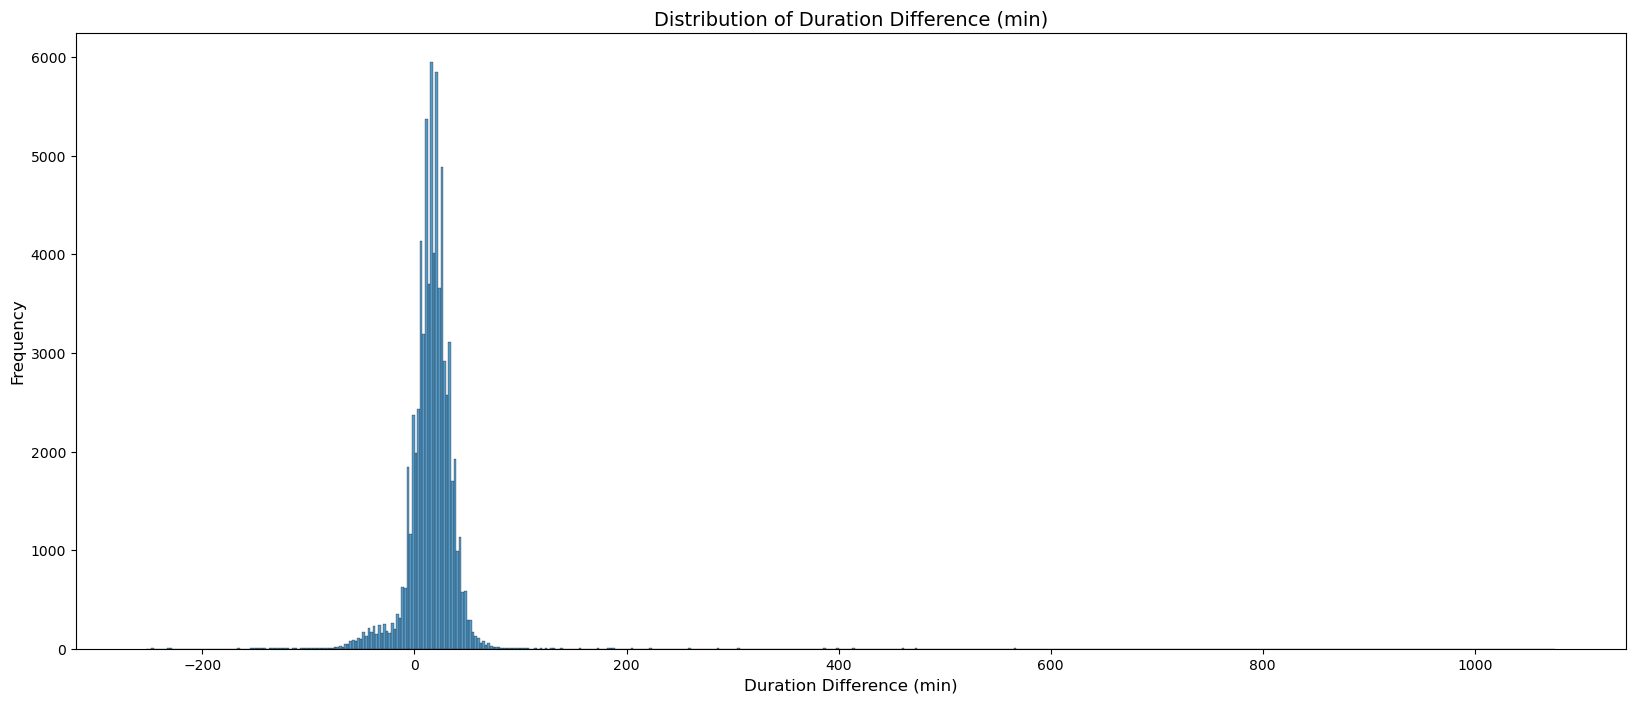

In [45]:
plt.figure(figsize=(20, 8))
sns.histplot(df['duration_difference_min'])
plt.title('Distribution of Duration Difference (min)', fontsize=14)
plt.xlabel('Duration Difference (min)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

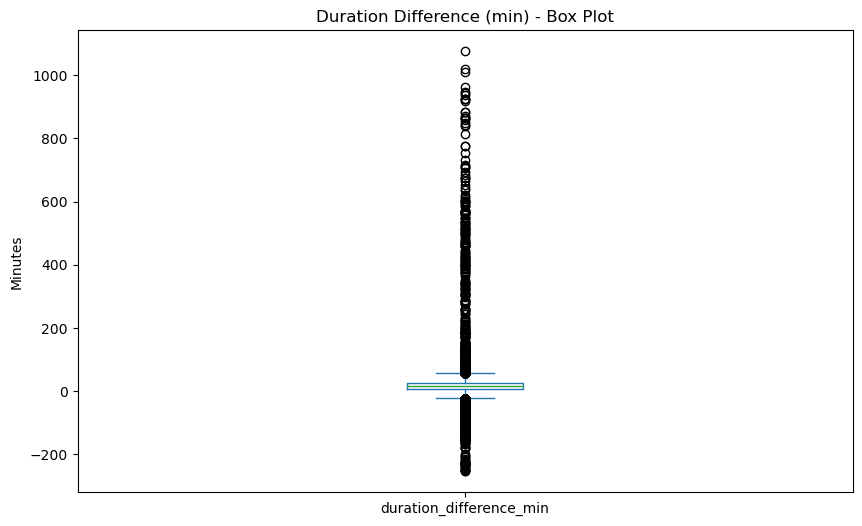

count    72924.000000
mean        16.695615
std         33.262709
min       -253.000000
25%          7.000000
50%         17.000000
75%         27.000000
max       1076.000000
Name: duration_difference_min, dtype: float64


In [38]:
plt.figure(figsize=(10, 6))
df['duration_difference_min'].plot(kind='box')
plt.title('Duration Difference (min) - Box Plot')
plt.ylabel('Minutes')
plt.show()

print(df['duration_difference_min'].describe())

In [44]:
Q1 = df['duration_difference_min'].quantile(0.25)
Q3 = df['duration_difference_min'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

within_box = df[(df['duration_difference_min'] >= lower_fence) & 
                (df['duration_difference_min'] <= upper_fence)]
outliers = df[(df['duration_difference_min'] < lower_fence) | 
              (df['duration_difference_min'] > upper_fence)]

print(f"Q1:                  {Q1}")
print(f"Q3:                  {Q3}")
print(f"IQR:                 {IQR}")
print(f"Lower fence:         {lower_fence}")
print(f"Upper fence:         {upper_fence}")
print(f"Values within box:   {len(within_box):,} ({len(within_box)/len(df)*100:.1f}%)")
print(f"Outliers:            {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Outliers below:      {len(df[df['duration_difference_min'] < lower_fence]):,}")
print(f"Outliers above:      {len(df[df['duration_difference_min'] > upper_fence]):,}")

Q1:                  7.0
Q3:                  27.0
IQR:                 20.0
Lower fence:         -23.0
Upper fence:         57.0
Values within box:   69,308 (74.9%)
Outliers:            3,616 (3.9%)
Outliers below:      2,794
Outliers above:      822
